# Wörterbuchbasierte Sentimentanalyse




In [1]:
# Bibliotheken und packages laden

import os
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import sent_tokenize
import re

In [2]:
# Daten aus dem NYT-Korpus einlesen


df_articles = pd.read_csv(
    "samples_sentencelvl_with_dates_and_sentiment.csv",
    sep=";",                    
    encoding= 'latin1',
    header=0,
    on_bad_lines='skip',
    keep_default_na=False
)

print("✓ CSV loaded.")
print("Columns detected:", list(df_articles.columns))




✓ CSV loaded.
Columns detected: ['ID', 'extracted_text', 'Datum_standardisiert', 'sentiment_final']


## Analyse mit Harvard IV-4 dictionary 

In [3]:
import pysentiment2 as ps

# Harvard IV-4 dictionary initialisieren 
hiv4 = ps.HIV4()

def analyze_with_hiv4(text):  
    tokens = hiv4.tokenize(text)  
    score = hiv4.get_score(tokens)  
    return score

# Iteration über alle Artikel
df_articles['HIV4_Positive'] = df_articles['extracted_text'].apply(lambda x: analyze_with_hiv4(x)['Positive'])
df_articles['HIV4_Negative'] = df_articles['extracted_text'].apply(lambda x: analyze_with_hiv4(x)['Negative'])
df_articles['HIV4_Polarity'] = df_articles['extracted_text'].apply(lambda x: analyze_with_hiv4(x)['Polarity'])


print("Harvard IV-4 Sentiment Analysis Results:")
print(df_articles[['ID', 'HIV4_Positive', 'HIV4_Negative', 'HIV4_Polarity']])

Harvard IV-4 Sentiment Analysis Results:
          ID  HIV4_Positive  HIV4_Negative  HIV4_Polarity
0          1              2              4      -0.333333
1          2              8              6       0.142857
2          2             11              8       0.157895
3          2              8              6       0.142857
4          2              5              5       0.000000
...      ...            ...            ...            ...
59480  13345              6             11      -0.294118
59481  13346              6              5       0.090909
59482  13346              4              1       0.600000
59483  13347              2             12      -0.714286
59484  13347              2              5      -0.428571

[59485 rows x 4 columns]


In [4]:
# Sortieren der Artikel nach Polarity-Wert
sorted_articles = df_articles.sort_values(by='HIV4_Polarity')

# Die fünf Artikel mit den höchsten Polarity-Werten
top_positive_articles = sorted_articles.tail(5)

# Die fünf Artikel mit den niedrigsten Polarity-Werten
top_negative_articles = sorted_articles.head(5)

print("Top 5 Artikel mit den höchsten Polarity-Werten:")
print(top_positive_articles[['ID', 'HIV4_Polarity', 'extracted_text']])

print("\nTop 5 Artikel mit den niedrigsten Polarity-Werten:")
print(top_negative_articles[['ID', 'HIV4_Polarity', 'extracted_text']])


Top 5 Artikel mit den höchsten Polarity-Werten:
          ID  HIV4_Polarity                                     extracted_text
345      103            1.0  Formal diplomatic relations were established i...
8797    2187            1.0  Canadian Is Honored By U.S. Energy Dept. A Can...
49505  11444            1.0  4. DECIDES that the Special Commission, in the...
12572   3032            1.0  Energy Department to Give $226 Million to Supp...
15335   3664            1.0  Mr. Dubinin is to become the Ambassador to the...

Top 5 Artikel mit den niedrigsten Polarity-Werten:
          ID  HIV4_Polarity                                     extracted_text
507      144           -1.0  They were taken into custody as about 20 peopl...
1918     510           -1.0  The issue is not only that conventional war co...
42313   9956           -1.0  Comparing a group of service members who took ...
32320   7734           -1.0  At 8:15 a.m. local time, the bomb known to its...
46736  10890           -1.0  Th

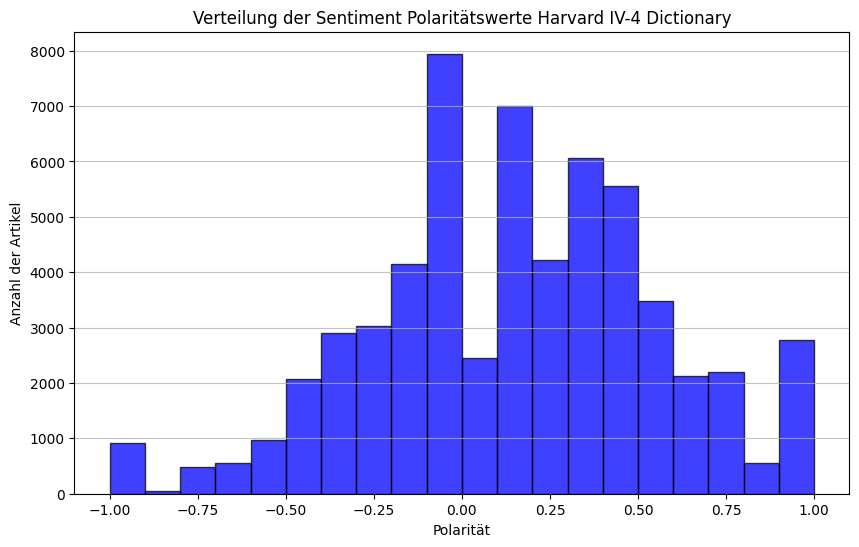

In [5]:
#Verteilung der Polaritäten
import matplotlib.pyplot as plt

polarity_values = df_articles['HIV4_Polarity']

# Plot der Verteilung der Polarity-Werte
plt.figure(figsize=(10, 6))
plt.hist(polarity_values, bins=20, alpha=0.75, color='blue', edgecolor='black')

# Beschriftungen und Titel
plt.xlabel('Polarität')
plt.ylabel('Anzahl der Artikel')
plt.title('Verteilung der Sentiment Polaritätswerte Harvard IV-4 Dictionary')

#Speichern des Plots
#plt.savefig("Harvard4_Senitmentwerte.png", dpi=600, bbox_inches='tight')

# Anzeigen des Plots
plt.grid(axis='y', alpha=0.75)
plt.show()



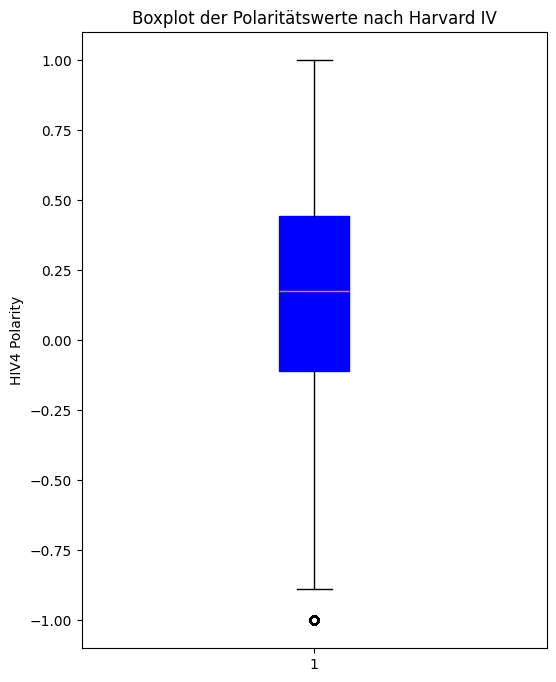

In [6]:
import matplotlib.pyplot as plt

# Boxplot für die HIV4_Polarity-Werte
plt.figure(figsize=(6, 8))
plt.boxplot(df_articles["HIV4_Polarity"], vert=True, patch_artist=True, boxprops=dict(facecolor='blue', color='blue'))

# Achsenbeschriftung und Titel
plt.ylabel("HIV4 Polarity")
plt.title("Boxplot der Polaritätswerte nach Harvard IV")

plt.show()


In [7]:
#Durchschnittswerte berechnen
mean_val = df_articles["HIV4_Polarity"].mean()
median_val = df_articles["HIV4_Polarity"].median()

print(f"Arithmetisches Mittel: {mean_val:.3f}")
print(f"Median: {median_val:.3f}")

num_extreme_negative = df_articles[df_articles['HIV4_Polarity'] <= -0.9].shape[0]
num_negative = df_articles[df_articles['HIV4_Polarity'] <= -0.05].shape[0]
num_neutral  = df_articles[(df_articles['HIV4_Polarity']> -0.05) & (df_articles['HIV4_Polarity'] < 0.05)].shape[0]
num_positive = df_articles[df_articles['HIV4_Polarity'] >= 0.5].shape[0]
num_extreme_positive = df_articles[df_articles['HIV4_Polarity'] >= 0.9].shape[0]



print(f"Anzahl stark negativer Artikel (≤ -0.9): {num_extreme_negative}")
print(f"Anzahl negativer Artikel (≤ -0.05): {num_negative}")
print(f"Anzahl neutraler Artikel (≈ 0): {num_neutral}")
print(f"Anzahl positiver Artikel (≥ 0.05): {num_positive}")
print(f"Anzahl stark positiver Artikel (≥ 0.9): {num_extreme_positive}")

Arithmetisches Mittel: 0.164
Median: 0.176
Anzahl stark negativer Artikel (≤ -0.9): 912
Anzahl negativer Artikel (≤ -0.05): 16829
Anzahl neutraler Artikel (≈ 0): 6461
Anzahl positiver Artikel (≥ 0.05): 11141
Anzahl stark positiver Artikel (≥ 0.9): 2780


In [8]:
# Datum in "datetime" umwandeln
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'])

# Monat extrahieren (z. B. 2023-07) und als neue Spalte speichern (optional)
df_articles['Monat'] = df_articles['Datum_standardisiert'].dt.to_period('M')

# Durchschnittlicher Sentimentwert pro Monat
monthly_sentiment = df_articles.groupby('Monat')['HIV4_Polarity'].mean().reset_index()

# Für bessere Visualisierung: Periode wieder zu Timestamp umwandeln
monthly_sentiment['Monat'] = monthly_sentiment['Monat'].dt.to_timestamp()



In [9]:
# Höchster durchschnittlicher Sentimentwert (Monat)
max_sentiment = monthly_sentiment.loc[monthly_sentiment['HIV4_Polarity'].idxmax()]
print("Monat mit höchstem durchschnittlichen Sentiment:")
print(max_sentiment)

# Niedrigster durchschnittlicher Sentimentwert (Monat)
min_sentiment = monthly_sentiment.loc[monthly_sentiment['HIV4_Polarity'].idxmin()]
print("\nMonat mit niedrigstem durchschnittlichen Sentiment:")
print(min_sentiment)


Monat mit höchstem durchschnittlichen Sentiment:
Monat            2019-12-01 00:00:00
HIV4_Polarity               0.510227
Name: 473, dtype: object

Monat mit niedrigstem durchschnittlichen Sentiment:
Monat            2001-09-01 00:00:00
HIV4_Polarity              -0.130714
Name: 254, dtype: object


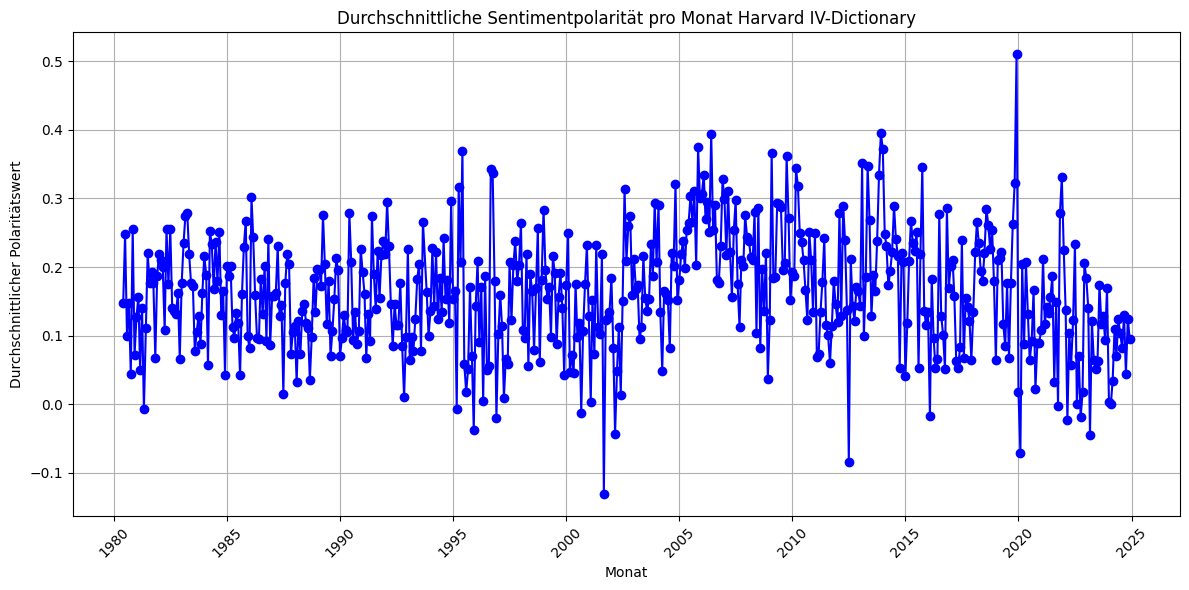

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(monthly_sentiment['Monat'], monthly_sentiment['HIV4_Polarity'],
         marker='o', linestyle='-', color='blue')

plt.title('Durchschnittliche Sentimentpolarität pro Monat Harvard IV-Dictionary')
plt.xlabel('Monat')
plt.ylabel('Durchschnittlicher Polaritätswert')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
#Speichern des Plots
plt.savefig("Harvard4_Zeitverlauf.png", dpi=600, bbox_inches='tight')
plt.show()



In [11]:
#Varianzanalyse (ANOVA)
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Sicherstellen, dass Monat ein String oder Category ist
df_articles['Monat'] = df_articles['Monat'].astype(str)  
# oder:
df_articles['Monat'] = df_articles['Monat'].astype('category')

# ANOVA mit statsmodels
model = ols('HIV4_Polarity ~ C(Monat)', data=df_articles).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)


               sum_sq       df         F         PR(>F)
C(Monat)   421.292150    534.0  4.758487  1.208477e-250
Residual  9773.656638  58950.0       NaN            NaN


In [12]:
#Signifikante Unterschiede zwischen aufeinander folgenden Monaten 
from scipy.stats import ttest_ind
import pandas as pd

# Sicherstellen, dass 'Monat' als Datum vorliegt
df_articles['Monat_dt'] = pd.to_datetime(df_articles['Monat'], errors='coerce')

# NaT-Werte entfernen
df_clean = df_articles.dropna(subset=['Monat_dt'])

# Alle eindeutigen Monate sortieren
months_sorted = sorted(df_clean['Monat_dt'].unique())

results = []
for i in range(len(months_sorted)-1):
    m1, m2 = months_sorted[i], months_sorted[i+1]
    
    group1 = df_clean[df_clean['Monat_dt'] == m1]['HIV4_Polarity']
    group2 = df_clean[df_clean['Monat_dt'] == m2]['HIV4_Polarity']
    
    if len(group1) > 1 and len(group2) > 1:  # nur testen, wenn genug Daten
        stat, p = ttest_ind(group1, group2, equal_var=False)  # Welch-Test
        results.append({
            "Monat_1": m1.strftime("%Y-%m"),
            "Monat_2": m2.strftime("%Y-%m"),
            "Mittelwert_1": group1.mean(),
            "Mittelwert_2": group2.mean(),
            "t-Statistik": stat,
            "p-Wert": p
        })

df_results = pd.DataFrame(results)

# Nur signifikante Unterschiede behalten
df_sig = df_results[df_results["p-Wert"] < 0.05]

print("Signifikante Unterschiede zwischen aufeinanderfolgenden Monaten:")
print(df_sig if not df_sig.empty else "Keine signifikanten Unterschiede gefunden.")


Signifikante Unterschiede zwischen aufeinanderfolgenden Monaten:
     Monat_1  Monat_2  Mittelwert_1  Mittelwert_2  t-Statistik    p-Wert
1    1980-07  1980-08      0.247966      0.099487     2.972623  0.003289
3    1980-09  1980-10      0.147595      0.044269     1.995964  0.047238
4    1980-10  1980-11      0.044269      0.255928    -3.748236  0.000226
5    1980-11  1980-12      0.255928      0.071460     3.366445  0.000903
8    1981-02  1981-03      0.156829      0.050519     2.200834  0.028835
..       ...      ...           ...           ...          ...       ...
508  2022-11  2022-12      0.017187      0.206036    -3.870320  0.000135
511  2023-02  2023-03      0.140048     -0.044727     3.166382  0.002007
512  2023-03  2023-04     -0.044727      0.121790    -3.254909  0.001277
516  2023-07  2023-08      0.063263      0.173651    -2.786954  0.005573
521  2023-12  2024-01      0.169138      0.003836     2.504615  0.013328

[118 rows x 6 columns]


In [13]:
import pandas as pd

# Datum in Datetime umwandeln
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'], errors='coerce')

# Jahres-Periode berechnen 
df_articles['Jahr'] = df_articles['Datum_standardisiert'].dt.to_period("Y")

# Durchschnittliche Polarität pro Halbjahr
jahr_sentiment = (
    df_articles.groupby('Jahr')['HIV4_Polarity']
    .mean()
    .reset_index()
)

# Für bessere Plots wieder in Timestamp umwandeln
jahr_sentiment['Jahr'] = jahr_sentiment['Jahr'].dt.to_timestamp()

print("Durchschnittliche Polarität Harvard IV pro Jahr:")
print(jahr_sentiment)


Durchschnittliche Polarität Harvard IV pro Jahr:
         Jahr  HIV4_Polarity
0  1980-01-01       0.147344
1  1981-01-01       0.129888
2  1982-01-01       0.165760
3  1983-01-01       0.176884
4  1984-01-01       0.180241
5  1985-01-01       0.146098
6  1986-01-01       0.137748
7  1987-01-01       0.157389
8  1988-01-01       0.116222
9  1989-01-01       0.184860
10 1990-01-01       0.136852
11 1991-01-01       0.177262
12 1992-01-01       0.159389
13 1993-01-01       0.140334
14 1994-01-01       0.182633
15 1995-01-01       0.143952
16 1996-01-01       0.147600
17 1997-01-01       0.140768
18 1998-01-01       0.125577
19 1999-01-01       0.146328
20 2000-01-01       0.117351
21 2001-01-01       0.117283
22 2002-01-01       0.152819
23 2003-01-01       0.183662
24 2004-01-01       0.206326
25 2005-01-01       0.266269
26 2006-01-01       0.276617
27 2007-01-01       0.228984
28 2008-01-01       0.187403
29 2009-01-01       0.240889
30 2010-01-01       0.223086
31 2011-01-01       0.1

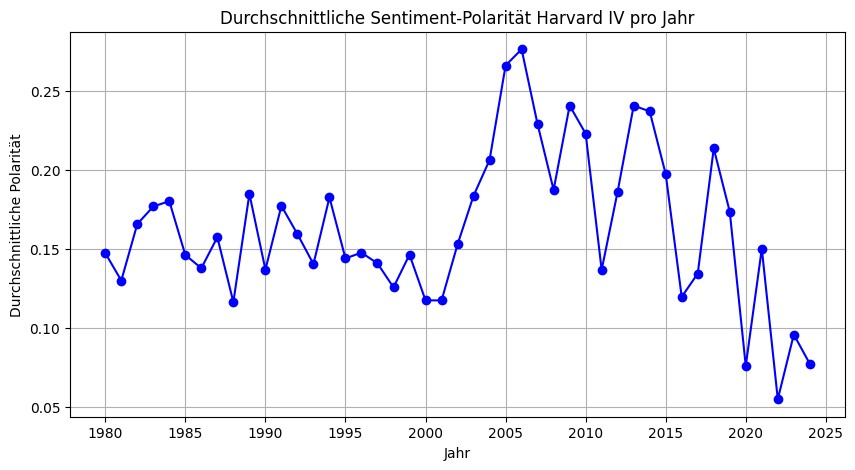

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(jahr_sentiment['Jahr'], jahr_sentiment['HIV4_Polarity'],
         marker='o', linestyle='-', color='blue')

plt.title("Durchschnittliche Sentiment-Polarität Harvard IV pro Jahr")
plt.xlabel("Jahr")
plt.ylabel("Durchschnittliche Polarität")
plt.grid(True)
plt.show()


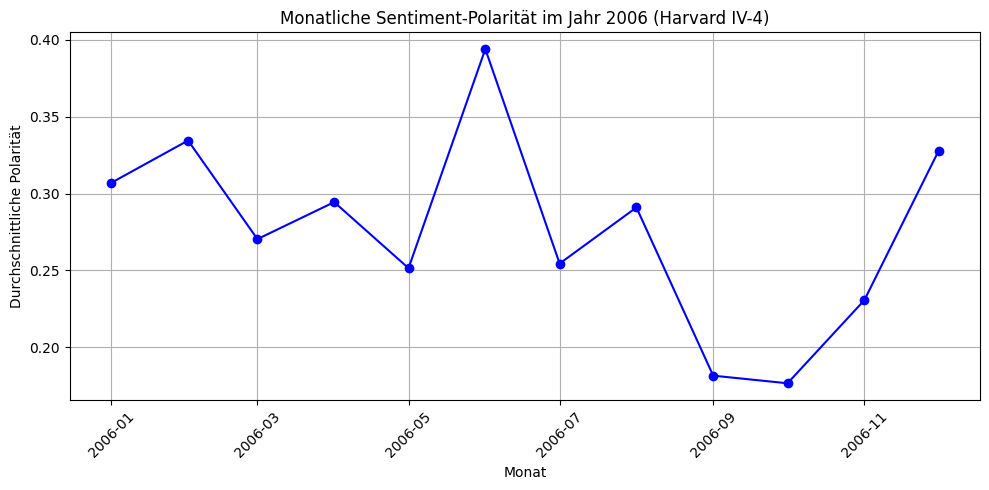

In [15]:
import matplotlib.pyplot as plt

# Sicherstellen, dass das Datum korrekt ist
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'], errors='coerce')

# Nur Daten aus 2006
df_2006 = df_articles[df_articles['Datum_standardisiert'].dt.year == 2006]

# Monatsweise aggregieren
monthly_2006 = (
    df_2006.groupby(df_2006['Datum_standardisiert'].dt.to_period("M"))['HIV4_Polarity']
    .mean()
    .reset_index()
)

# Für Plots in Timestamp umwandeln
monthly_2006['Datum_standardisiert'] = monthly_2006['Datum_standardisiert'].dt.to_timestamp()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_2006['Datum_standardisiert'], monthly_2006['HIV4_Polarity'],
         marker='o', linestyle='-', color='blue')

plt.title("Monatliche Sentiment-Polarität im Jahr 2006 (Harvard IV-4)")
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Polarität")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


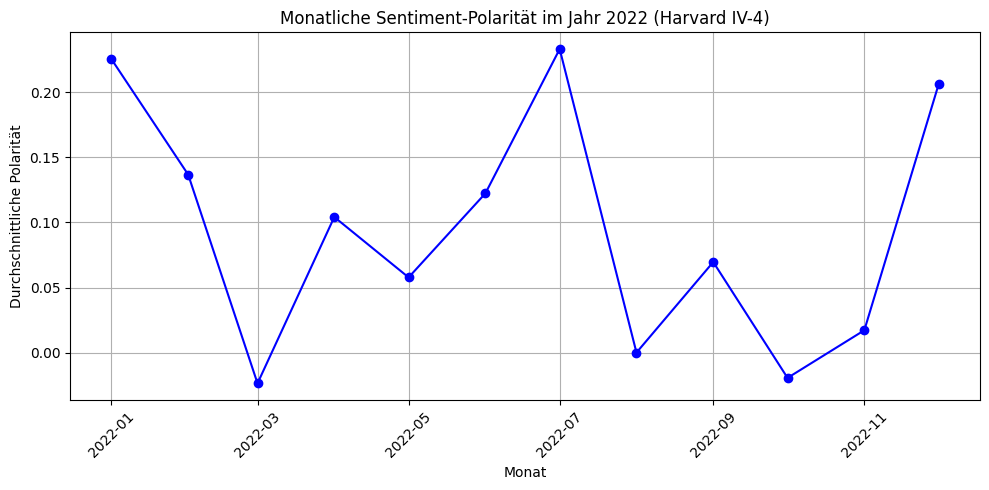

In [16]:
import matplotlib.pyplot as plt

# Sicherstellen, dass das Datum korrekt ist
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'], errors='coerce')

# Nur Daten aus 2022
df_2022 = df_articles[df_articles['Datum_standardisiert'].dt.year == 2022]

# Monatsweise aggregieren
monthly_2022 = (
    df_2022.groupby(df_2022['Datum_standardisiert'].dt.to_period("M"))['HIV4_Polarity']
    .mean()
    .reset_index()
)

# Für Plots in Timestamp umwandeln
monthly_2022['Datum_standardisiert'] = monthly_2022['Datum_standardisiert'].dt.to_timestamp()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_2022['Datum_standardisiert'], monthly_2022['HIV4_Polarity'],
         marker='o', linestyle='-', color='blue')

plt.title("Monatliche Sentiment-Polarität im Jahr 2022 (Harvard IV-4)")
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Polarität")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


In [17]:
# Sicherstellen, dass Datum korrekt ist
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'], errors='coerce')

# Filter: Juni 2006
juni_2006 = df_articles[
    (df_articles['Datum_standardisiert'].dt.year == 2006) &
    (df_articles['Datum_standardisiert'].dt.month == 6)
]

# Nur die Spalte mit den Textsnippets anzeigen
print(f"Anzahl Textsnippets im Juni 2006: {len(juni_2006)}")
print(juni_2006[['Datum_standardisiert', 'extracted_text']])


Anzahl Textsnippets im Juni 2006: 146
      Datum_standardisiert                                     extracted_text
4765            2006-06-15  Kommersant quoted an unnamed official in the F...
4766            2006-06-15  The station will also be the first in a planne...
5257            2006-06-18  At the Heart of the United Front on Iran, Vagu...
5258            2006-06-18  Iran has long insisted that it will never give...
5259            2006-06-18  Like others interviewed for this article, the ...
...                    ...                                                ...
51651           2006-06-04  Mr. Bush's search for a new option was driven,...
51652           2006-06-04  But it is unclear whether he is an enthusiast,...
51653           2006-06-04  But it took weeks over the winter to get the w...
51654           2006-06-04  Mr. Bush, one aide noted, was receiving specia...
51655           2006-06-04  He must hold together countries that bitterly ...

[146 rows x 2 columns]


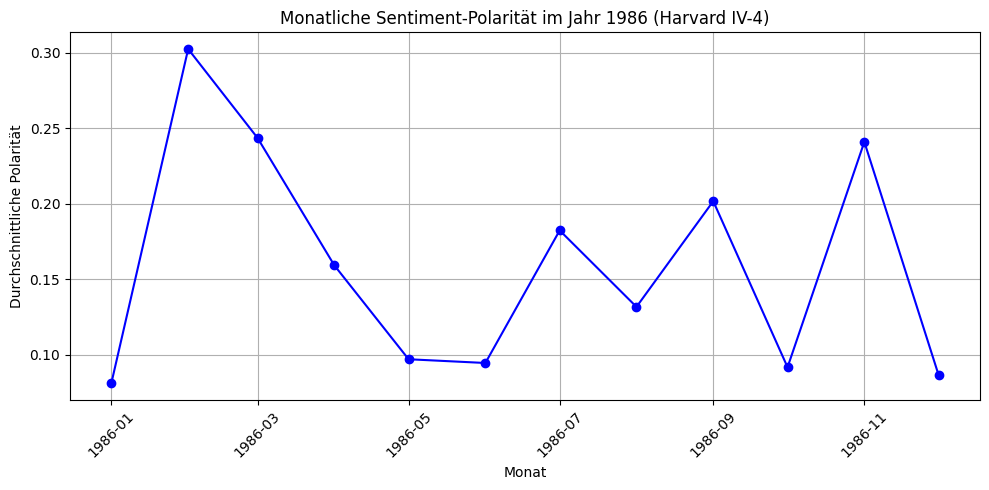

In [18]:
import matplotlib.pyplot as plt

# Sicherstellen, dass das Datum korrekt ist
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'], errors='coerce')

# Nur Daten aus 2006
df_1986 = df_articles[df_articles['Datum_standardisiert'].dt.year == 1986]

# Monatsweise aggregieren
monthly_1986 = (
    df_1986.groupby(df_1986['Datum_standardisiert'].dt.to_period("M"))['HIV4_Polarity']
    .mean()
    .reset_index()
)

# Für Plots in Timestamp umwandeln
monthly_1986['Datum_standardisiert'] = monthly_1986['Datum_standardisiert'].dt.to_timestamp()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_1986['Datum_standardisiert'], monthly_1986['HIV4_Polarity'],
         marker='o', linestyle='-', color='blue')

plt.title("Monatliche Sentiment-Polarität im Jahr 1986 (Harvard IV-4)")
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Polarität")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


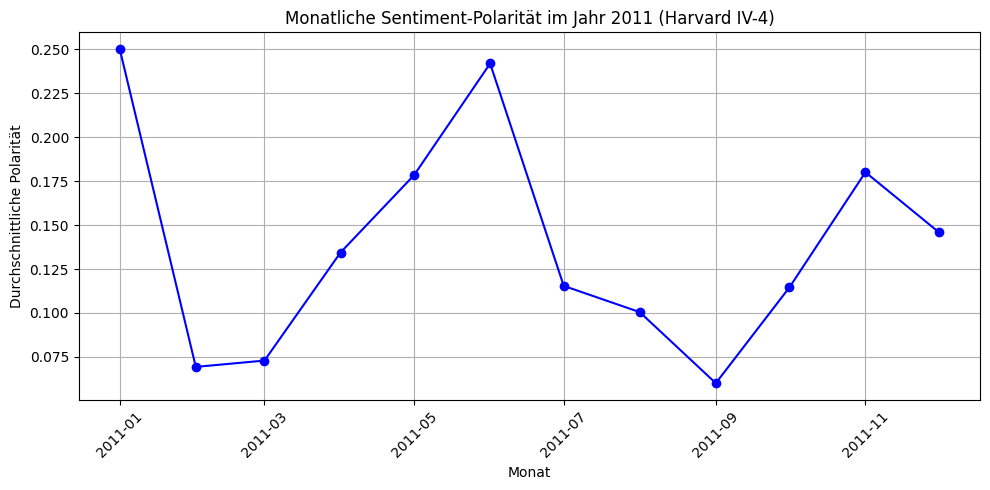

In [19]:
import matplotlib.pyplot as plt

# Sicherstellen, dass das Datum korrekt ist
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'], errors='coerce')

# Nur Daten aus 2011
df_2011 = df_articles[df_articles['Datum_standardisiert'].dt.year == 2011]

# Monatsweise aggregieren
monthly_2011 = (
    df_2011.groupby(df_2011['Datum_standardisiert'].dt.to_period("M"))['HIV4_Polarity']
    .mean()
    .reset_index()
)

# Für Plots in Timestamp umwandeln
monthly_2011['Datum_standardisiert'] = monthly_2011['Datum_standardisiert'].dt.to_timestamp()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_2011['Datum_standardisiert'], monthly_2011['HIV4_Polarity'],
         marker='o', linestyle='-', color='blue')

plt.title("Monatliche Sentiment-Polarität im Jahr 2011 (Harvard IV-4)")
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Polarität")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


## VADER (Valence Aware Dictionary and sEntiment Reasoner)

In [20]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download VADER lexicon
nltk.download('vader_lexicon')

# VADER initialisieren
sid = SentimentIntensityAnalyzer()

def analyze_with_vader(Artikeltext):
    return sid.polarity_scores(Artikeltext)

# VADER über alle Artikelsnippets iterieren lassen
df_articles['VADER_Negative'] = df_articles['extracted_text'].apply(lambda x: analyze_with_vader(x)['neg'])
df_articles['VADER_Neutral'] = df_articles['extracted_text'].apply(lambda x: analyze_with_vader(x)['neu'])
df_articles['VADER_Positive'] = df_articles['extracted_text'].apply(lambda x: analyze_with_vader(x)['pos'])
df_articles['VADER_Compound'] = df_articles['extracted_text'].apply(lambda x: analyze_with_vader(x)['compound'])

# Ergebnisse
print(df_articles[['ID', 'VADER_Negative', 'VADER_Neutral', 'VADER_Positive', 'VADER_Compound']])

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\s-kup\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


          ID  VADER_Negative  VADER_Neutral  VADER_Positive  VADER_Compound
0          1           0.045          0.778           0.177          0.8481
1          2           0.078          0.869           0.053         -0.4939
2          2           0.084          0.793           0.123          0.6858
3          2           0.026          0.905           0.069          0.3612
4          2           0.088          0.757           0.155          0.4215
...      ...             ...            ...             ...             ...
59480  13345           0.147          0.837           0.016         -0.9704
59481  13346           0.211          0.632           0.157         -0.7452
59482  13346           0.034          0.868           0.098          0.5234
59483  13347           0.138          0.796           0.066         -0.8854
59484  13347           0.247          0.621           0.132         -0.7140

[59485 rows x 5 columns]


In [21]:
# Sortieren der Artikel nach Polarity-Wert
sorted_articles = df_articles.sort_values(by='VADER_Compound')

# Die fünf Artikel mit den höchsten Polarity-Werten
top_positive_articles = sorted_articles.tail(5)

# Die fünf Artikel mit den niedrigsten Polarity-Werten
top_negative_articles = sorted_articles.head(5)

print("Top 5 Artikel mit den höchsten Polarity-Werten:")
print(top_positive_articles[['ID', 'VADER_Compound', 'extracted_text']])

print("\nTop 5 Artikel mit den niedrigsten Polarity-Werten:")
print(top_negative_articles[['ID', 'VADER_Compound', 'extracted_text']])


Top 5 Artikel mit den höchsten Polarity-Werten:
          ID  VADER_Compound  \
53643  12468          0.9941   
48146  11145          0.9948   
28327   6856          0.9949   
40028   9428          0.9950   
53879  12510          0.9954   

                                          extracted_text  
53643  Nobel Peace Prize Winners Throughout History\n...  
48146  U.S. Seeks to Boost Nuclear Power After Decade...  
28327  We will do everything in our power to insure t...  
40028  ALMA-ATA DECLARATION\nTHE INDEPENDENT STATES -...  
53879  He was central to their development. Honors re...  

Top 5 Artikel mit den niedrigsten Polarity-Werten:
          ID  VADER_Compound  \
1409     374         -0.9987   
17747   4184         -0.9972   
13726   3302         -0.9971   
51359  11860         -0.9966   
30372   7273         -0.9965   

                                          extracted_text  
1409   A NATION CHALLENGED: ATOMIC ANXIETY; Threat of...  
17747  And this realization is now embedde

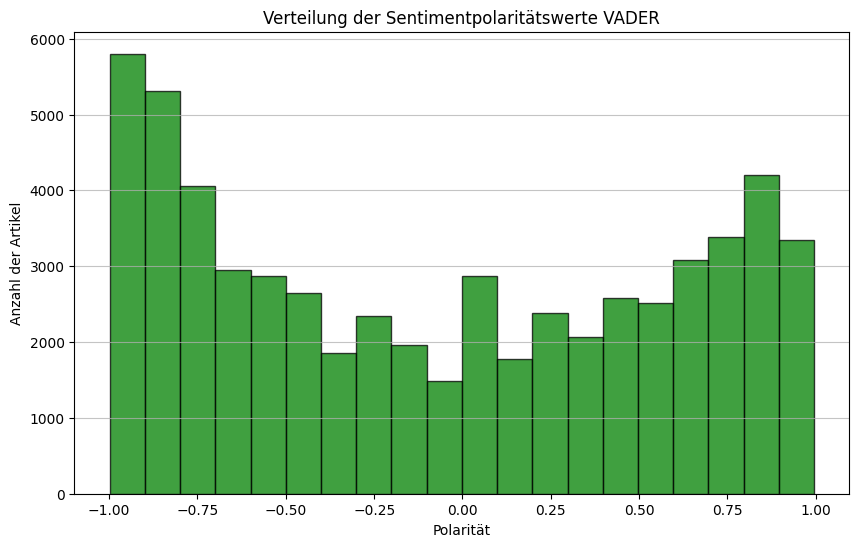

In [22]:
import matplotlib.pyplot as plt

polarity_values = df_articles['VADER_Compound']

# Plot der Verteilung der Polarity-Werte
plt.figure(figsize=(10, 6))
plt.hist(polarity_values, bins=20, alpha=0.75, color='green', edgecolor='black')

# Beschriftungen und Titel
plt.xlabel('Polarität')
plt.ylabel('Anzahl der Artikel')
plt.title('Verteilung der Sentimentpolaritätswerte VADER')

#Speichern des Plots
plt.savefig("VADER_Senitmentwerte.png", dpi=600, bbox_inches='tight')

# Anzeigen des Plots
plt.grid(axis='y', alpha=0.75)
plt.show()

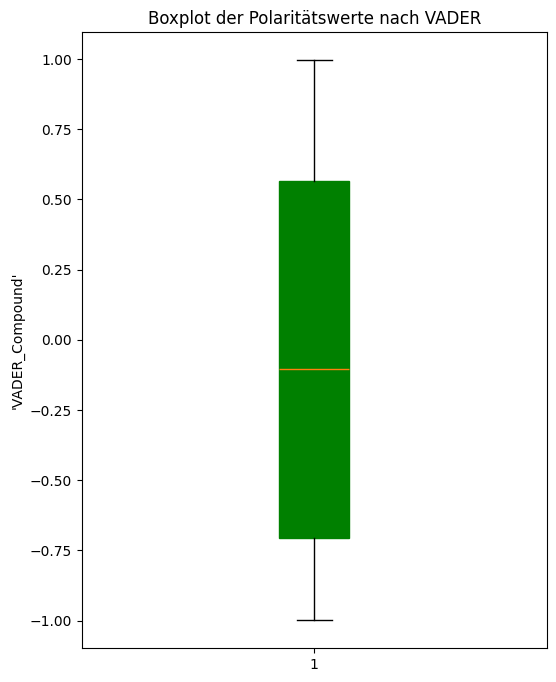

In [23]:
import matplotlib.pyplot as plt

# Boxplot für die HIV4_Polarity-Werte
plt.figure(figsize=(6, 8))
plt.boxplot(df_articles['VADER_Compound'], vert=True, patch_artist=True, boxprops=dict(facecolor='green', color='green'))


# Achsenbeschriftung und Titel
plt.ylabel("'VADER_Compound'")
plt.title("Boxplot der Polaritätswerte nach VADER")

plt.show()

In [24]:
#Durchschnittswerte berechnen
mean_val = df_articles["VADER_Compound"].mean()
median_val = df_articles["VADER_Compound"].median()
std_val = df_articles["VADER_Compound"].std()

print(f"Arithmetisches Mittel: {mean_val:.3f}")
print(f"Median: {median_val:.3f}")
print(f"Standardabweichung: {std_val:.3f}")

num_extreme_negative = df_articles[df_articles['VADER_Compound'] <= -0.9].shape[0]
num_negative = df_articles[df_articles['VADER_Compound'] <= -0.05].shape[0]
num_neutral  = df_articles[(df_articles['VADER_Compound'] > -0.05) & (df_articles['VADER_Compound'] < 0.05)].shape[0]
num_positive = df_articles[df_articles['VADER_Compound'] >= 0.5].shape[0]
num_extreme_positive = df_articles[df_articles['VADER_Compound'] >= 0.9].shape[0]

print(f"Anzahl stark negativer Artikel (≤ -0.9): {num_extreme_negative}")
print(f"Anzahl negativer Artikel (≤ -0.05): {num_negative}")
print(f"Anzahl neutraler Artikel (≈ 0): {num_neutral}")
print(f"Anzahl positiver Artikel (≥ 0.05): {num_positive}")
print(f"Anzahl stark positiver Artikel (≥ 0.9): {num_extreme_positive}")


Arithmetisches Mittel: -0.066
Median: -0.103
Standardabweichung: 0.648
Anzahl stark negativer Artikel (≤ -0.9): 5755
Anzahl negativer Artikel (≤ -0.05): 30633
Anzahl neutraler Artikel (≈ 0): 2594
Anzahl positiver Artikel (≥ 0.05): 16530
Anzahl stark positiver Artikel (≥ 0.9): 3157


In [25]:
# Datum in datetime umwandeln
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'])

# Monat extrahieren (z. B. 2023-07) und als neue Spalte speichern 
df_articles['Monat'] = df_articles['Datum_standardisiert'].dt.to_period('M')

# Durchschnittlicher Sentimentwert pro Monat
monthly_sentiment = df_articles.groupby('Monat')['VADER_Compound'].mean().reset_index()

# Für bessere Visualisierung: Periode wieder zu Timestamp umwandeln
monthly_sentiment['Monat'] = monthly_sentiment['Monat'].dt.to_timestamp()


In [26]:
# Höchster durchschnittlicher Sentimentwert (Monat)
max_sentiment = monthly_sentiment.loc[monthly_sentiment['VADER_Compound'].idxmax()]
print("Monat mit höchstem durchschnittlichen Sentiment:")
print(max_sentiment)

# Niedrigster durchschnittlicher Sentimentwert (Monat)
min_sentiment = monthly_sentiment.loc[monthly_sentiment['VADER_Compound'].idxmin()]
print("\nMonat mit niedrigstem durchschnittlichen Sentiment:")
print(min_sentiment)


Monat mit höchstem durchschnittlichen Sentiment:
Monat             1993-12-01 00:00:00
VADER_Compound                 0.8182
Name: 161, dtype: object

Monat mit niedrigstem durchschnittlichen Sentiment:
Monat             2022-10-01 00:00:00
VADER_Compound                -0.5062
Name: 507, dtype: object


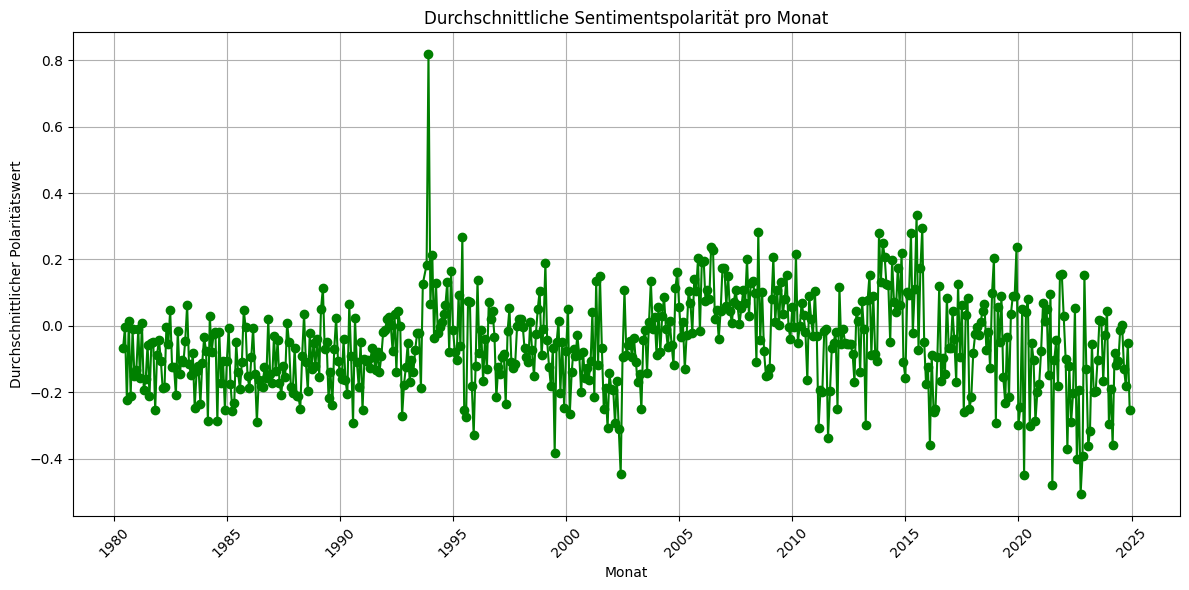

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(monthly_sentiment['Monat'], monthly_sentiment['VADER_Compound'],
         marker='o', linestyle='-', color='green')

plt.title('Durchschnittliche Sentimentspolarität pro Monat')
plt.xlabel('Monat')
plt.ylabel('Durchschnittlicher Polaritätswert')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

#Speichern des Plots
plt.savefig("VADER_Zeitverlauf.png", dpi=600, bbox_inches='tight')
plt.show()

In [28]:
import pandas as pd

# Sicherstellen, dass das Datum im richtigen Format vorliegt
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'], errors='coerce')

# Halbjahres-Periode berechnen (z. B. 2023H1, 2023H2)
df_articles['Jahr'] = df_articles['Datum_standardisiert'].dt.to_period("Y")

# Durchschnittliche Polarität pro Halbjahr
jahr_sentiment = (
    df_articles.groupby('Jahr')['VADER_Compound']
    .mean()
    .reset_index()
)

# Für bessere Plots wieder in Timestamp umwandeln
jahr_sentiment['Jahr'] = jahr_sentiment['Jahr'].dt.to_timestamp()

print("Durchschnittliche Polarität VADER pro Jahr:")
print(jahr_sentiment)


Durchschnittliche Polarität VADER pro Jahr:
         Jahr  VADER_Compound
0  1980-01-01       -0.081778
1  1981-01-01       -0.130642
2  1982-01-01       -0.101575
3  1983-01-01       -0.114847
4  1984-01-01       -0.104958
5  1985-01-01       -0.117332
6  1986-01-01       -0.172900
7  1987-01-01       -0.108704
8  1988-01-01       -0.117335
9  1989-01-01       -0.047448
10 1990-01-01       -0.121735
11 1991-01-01       -0.107098
12 1992-01-01       -0.044338
13 1993-01-01       -0.068746
14 1994-01-01        0.047800
15 1995-01-01       -0.073675
16 1996-01-01       -0.030205
17 1997-01-01       -0.086940
18 1998-01-01       -0.060816
19 1999-01-01       -0.109729
20 2000-01-01       -0.109278
21 2001-01-01       -0.124372
22 2002-01-01       -0.150665
23 2003-01-01       -0.060537
24 2004-01-01       -0.001289
25 2005-01-01        0.047088
26 2006-01-01        0.119034
27 2007-01-01        0.077968
28 2008-01-01        0.046828
29 2009-01-01        0.056058
30 2010-01-01        0.010

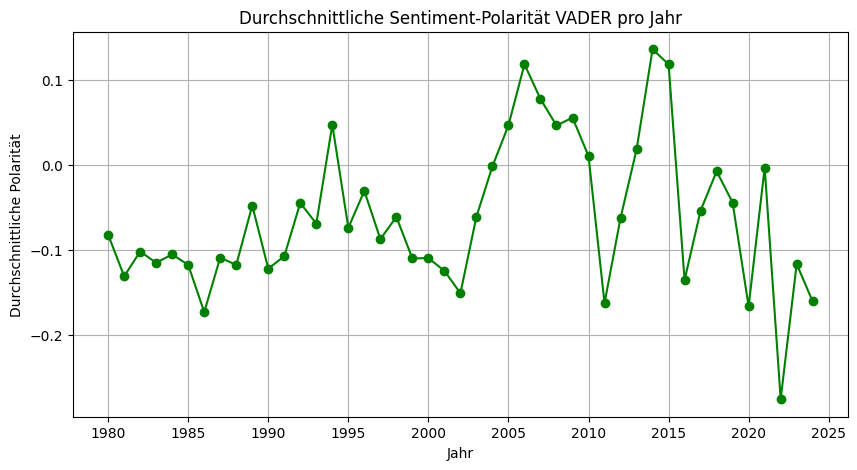

In [29]:
#Durchschnittliches Sentiment pro Jahr
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(jahr_sentiment['Jahr'], jahr_sentiment['VADER_Compound'],
         marker='o', linestyle='-', color='green')

plt.title("Durchschnittliche Sentiment-Polarität VADER pro Jahr")
plt.xlabel("Jahr")
plt.ylabel("Durchschnittliche Polarität")
plt.grid(True)
plt.show()


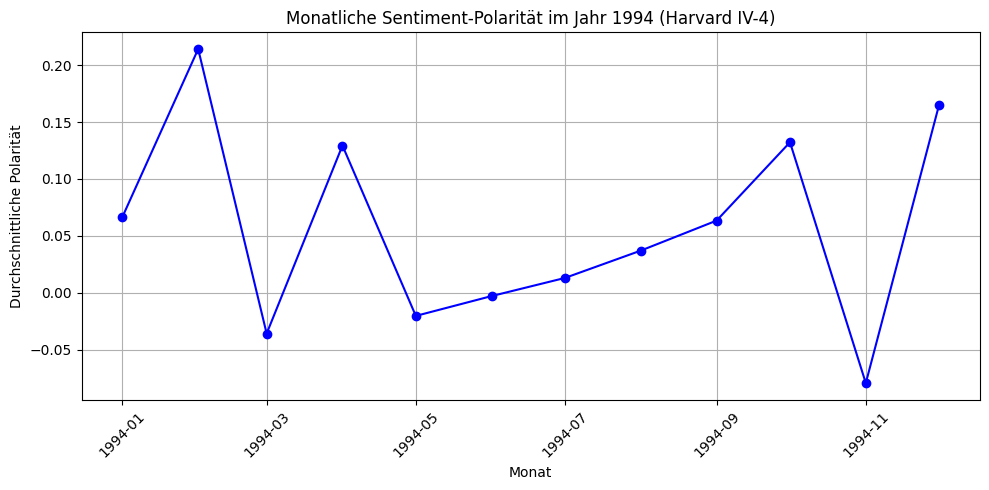

In [30]:
import matplotlib.pyplot as plt

# Sicherstellen, dass das Datum korrekt ist
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'], errors='coerce')

# Nur Daten aus 1994
df_1994 = df_articles[df_articles['Datum_standardisiert'].dt.year == 1994]

# Monatsweise aggregieren
monthly_1994 = (
    df_1994.groupby(df_1994['Datum_standardisiert'].dt.to_period("M"))['VADER_Compound']
    .mean()
    .reset_index()
)

# Für Plots in Timestamp umwandeln
monthly_1994['Datum_standardisiert'] = monthly_1994['Datum_standardisiert'].dt.to_timestamp()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_1994['Datum_standardisiert'], monthly_1994['VADER_Compound'],
         marker='o', linestyle='-', color='blue')

plt.title("Monatliche Sentiment-Polarität im Jahr 1994 (Harvard IV-4)")
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Polarität")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


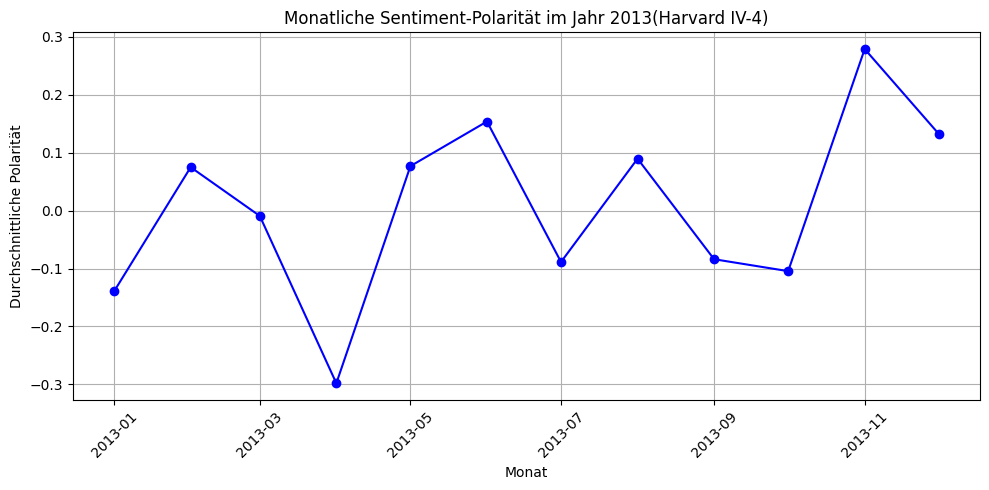

In [31]:
import matplotlib.pyplot as plt

# Sicherstellen, dass das Datum korrekt ist
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'], errors='coerce')

# Nur Daten aus 2013
df_2013 = df_articles[df_articles['Datum_standardisiert'].dt.year == 2013]

# Monatsweise aggregieren
monthly_2013 = (
    df_2013.groupby(df_2013['Datum_standardisiert'].dt.to_period("M"))['VADER_Compound']
    .mean()
    .reset_index()
)

# Für Plots in Timestamp umwandeln
monthly_2013['Datum_standardisiert'] = monthly_2013['Datum_standardisiert'].dt.to_timestamp()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_2013['Datum_standardisiert'], monthly_2013['VADER_Compound'],
         marker='o', linestyle='-', color='blue')

plt.title("Monatliche Sentiment-Polarität im Jahr 2013(Harvard IV-4)")
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Polarität")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


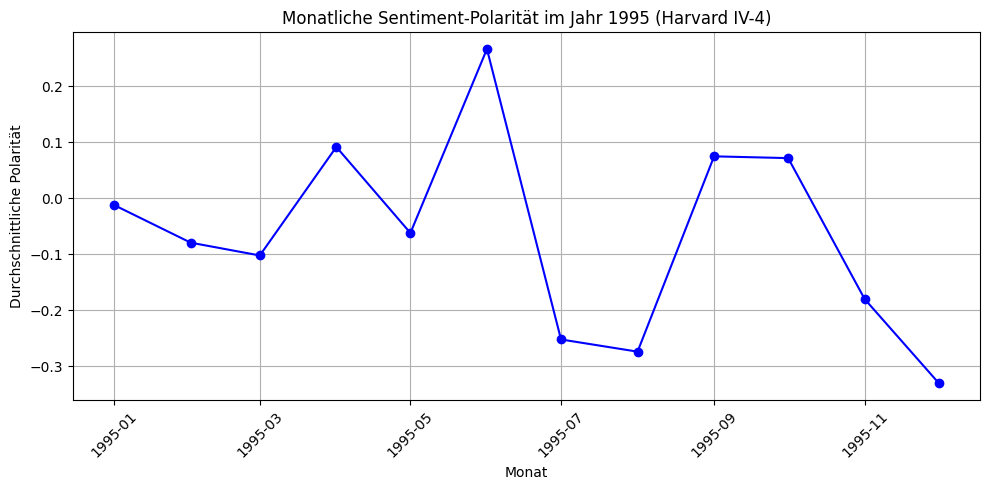

In [32]:
import matplotlib.pyplot as plt

# Sicherstellen, dass das Datum korrekt ist
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'], errors='coerce')

# Nur Daten aus 1995
df_1995 = df_articles[df_articles['Datum_standardisiert'].dt.year == 1995]

# Monatsweise aggregieren
monthly_1995 = (
    df_1995.groupby(df_1995['Datum_standardisiert'].dt.to_period("M"))['VADER_Compound']
    .mean()
    .reset_index()
)

# Für Plots in Timestamp umwandeln
monthly_1995['Datum_standardisiert'] = monthly_1995['Datum_standardisiert'].dt.to_timestamp()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_1995['Datum_standardisiert'], monthly_1995['VADER_Compound'],
         marker='o', linestyle='-', color='blue')

plt.title("Monatliche Sentiment-Polarität im Jahr 1995 (Harvard IV-4)")
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Polarität")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


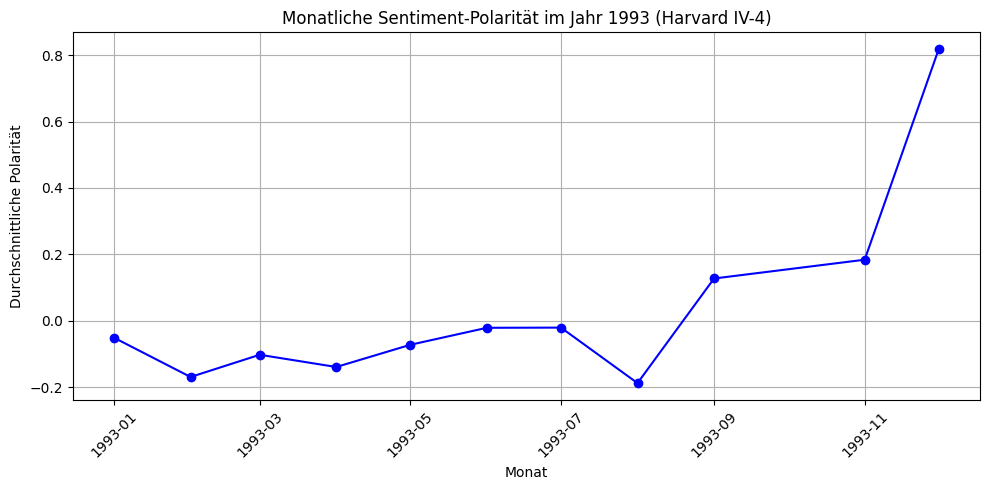

In [33]:
import matplotlib.pyplot as plt

# Sicherstellen, dass das Datum korrekt ist
df_articles['Datum_standardisiert'] = pd.to_datetime(df_articles['Datum_standardisiert'], errors='coerce')

# Nur Daten aus 1993
df_1993 = df_articles[df_articles['Datum_standardisiert'].dt.year == 1993]

# Monatsweise aggregieren
monthly_1993 = (
    df_1993.groupby(df_1993['Datum_standardisiert'].dt.to_period("M"))['VADER_Compound']
    .mean()
    .reset_index()
)

# Für Plots in Timestamp umwandeln
monthly_1993['Datum_standardisiert'] = monthly_1993['Datum_standardisiert'].dt.to_timestamp()

# Plot
plt.figure(figsize=(10,5))
plt.plot(monthly_1993['Datum_standardisiert'], monthly_1993['VADER_Compound'],
         marker='o', linestyle='-', color='blue')

plt.title("Monatliche Sentiment-Polarität im Jahr 1993 (Harvard IV-4)")
plt.xlabel("Monat")
plt.ylabel("Durchschnittliche Polarität")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


## Harvard IV und VADER im Vergleich



In [34]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from tqdm import tqdm

# Beispiel: df_articles mit 'filename' und 'Text'
# df_articles = pd.read_csv("deine_datei.csv")

# 1. Texte in Kleinbuchstaben umwandeln
df_articles["extracted_text"] = df_articles["extracted_text"].str.lower()

# 2. TF-IDF vorbereiten
vectorizer = TfidfVectorizer(stop_words='english', ngram_range=(1, 1), max_features=100)
X = vectorizer.fit_transform(df_articles["extracted_text"])
X_array = X.toarray()
feature_names = vectorizer.get_feature_names_out()

# 3. VADER initialisieren
analyzer = SentimentIntensityAnalyzer()

# 4. Analyse durchführen
all_results = []

for i, text in enumerate(tqdm(df_articles["extracted_text"], desc="🔍 Analysiere Artikel")):
    doc_vector = X_array[i]
    top_indices = doc_vector.argsort()[-10:][::-1]  # Top 10 Begriffe
    top_terms = [feature_names[idx].replace(" ", "_") for idx in top_indices]

    # Begriffe mit Sentimentwerten versehen
    term_scores = {}
    for term in top_terms:
        score = analyzer.lexicon.get(term)
        if score is None:
            score = 0.0  # Automatisch neutral
            analyzer.lexicon[term] = score
        term_scores[term] = score

    # Gesamtsentiment
    overall_sentiment = analyzer.polarity_scores(text)

    # Ergebnis speichern
    result = {
        'Article': text,
        'top_terms': top_terms,
        'term_scores': term_scores,
        'overall_sentiment': overall_sentiment
    }
    all_results.append(result)

# 5. Ergebnisse als DataFrame speichern
df_results = pd.DataFrame(all_results)
df_results.to_json("sentiment_ergebnisse_sentences.json", orient="records", lines=True)

print("\n✅ Analyse abgeschlossen. Ergebnisse gespeichert in 'sentiment_ergebnisse_sentences.json'.")


🔍 Analysiere Artikel: 100%|██████████| 59485/59485 [02:11<00:00, 453.47it/s] 



✅ Analyse abgeschlossen. Ergebnisse gespeichert in 'sentiment_ergebnisse_sentences.json'.


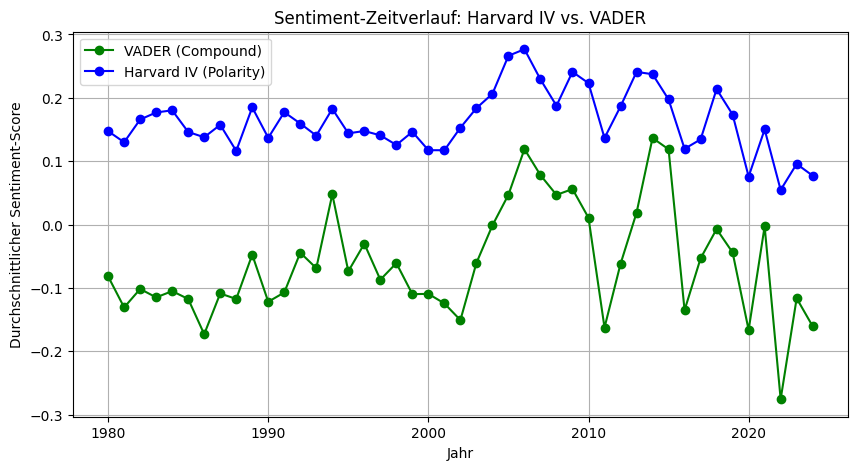

In [35]:
import matplotlib.pyplot as plt 
 

 # Jahr extrahieren
df_articles['Jahr'] = df_articles['Datum_standardisiert'].dt.year

# Gruppieren nach Jahr und Mittelwerte für beide Ansätze berechnen
jahr_sentiment = df_articles.groupby('Jahr')[['HIV4_Polarity', 'VADER_Compound']].mean().reset_index()


plt.figure(figsize=(10,5))
plt.plot(jahr_sentiment['Jahr'], jahr_sentiment['VADER_Compound'], marker='o', linestyle='-', color='green', label='VADER (Compound)')
plt.plot(jahr_sentiment['Jahr'], jahr_sentiment['HIV4_Polarity'], marker='o', linestyle='-', color='blue', label='Harvard IV (Polarity)')
plt.title('Sentiment-Zeitverlauf: Harvard IV vs. VADER')
plt.xlabel('Jahr')
plt.ylabel('Durchschnittlicher Sentiment-Score')
plt.legend()
plt.grid(True)
plt.legend(loc='best', fontsize=10)
plt.savefig("Sentimentvergleich_Harvard4_VADER-pro-Jahr.png", dpi=600, bbox_inches='tight')
plt.show()


In [36]:
#Durchschnittliche Distanz zwischen VADER und Harvard_IV

jahr_sentiment["Differenz"] = abs(
    jahr_sentiment["VADER_Compound"] - jahr_sentiment["HIV4_Polarity"]
)
durchschnittliche_abweichung = jahr_sentiment["Differenz"].mean()
print(f"Durchschnittliche Abweichung zwischen VADER und Harvard IV: {durchschnittliche_abweichung:.4f}")

Durchschnittliche Abweichung zwischen VADER und Harvard IV: 0.2242


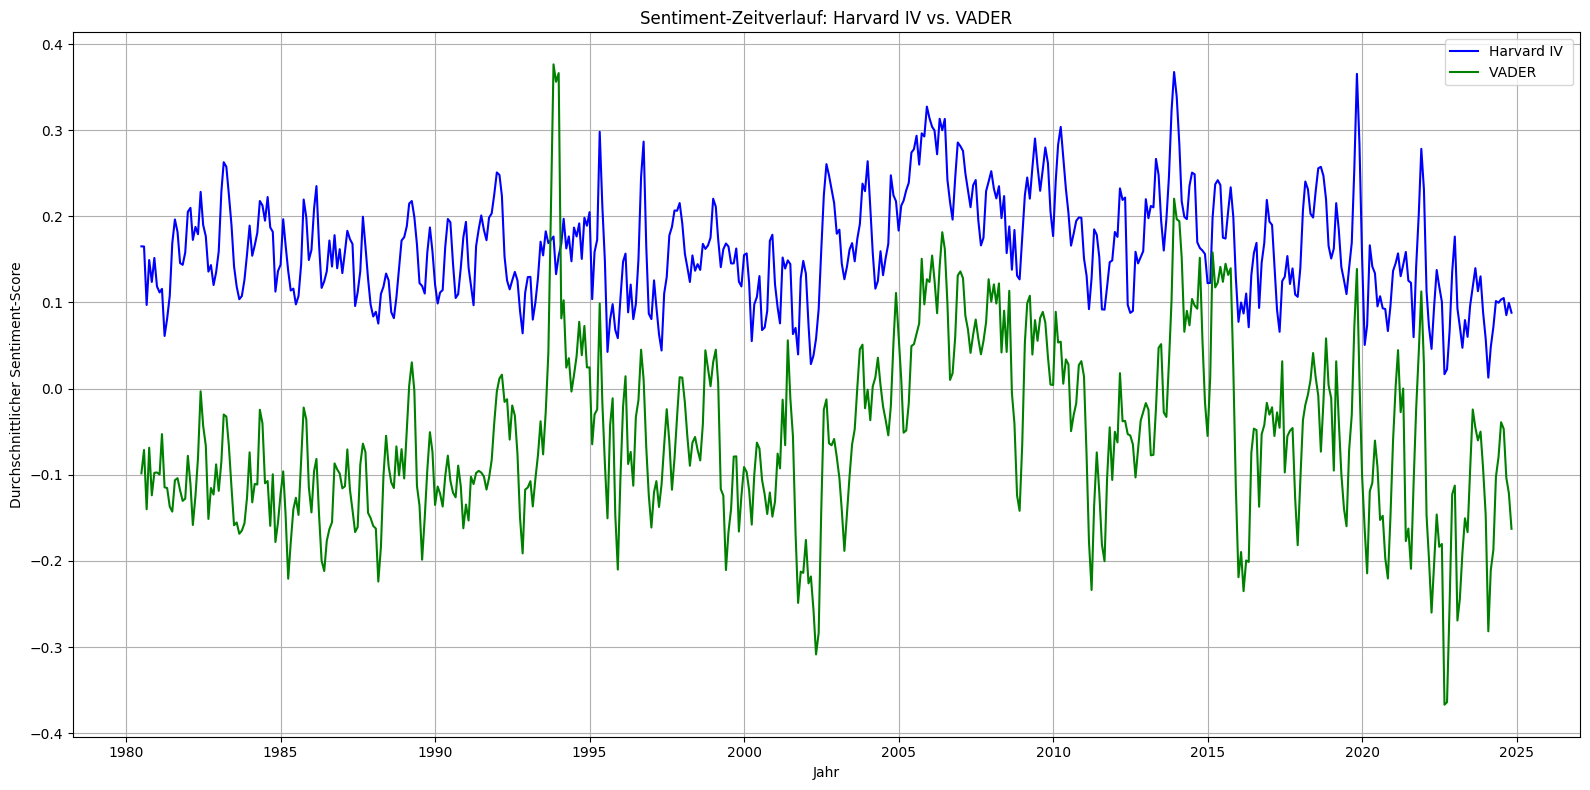

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

# Sicherstellen, dass 'Monat' datetime ist 
df_articles['Monat'] = df_articles['Monat'].dt.to_timestamp()

# Nach Monat gruppieren und Mittelwerte berechnen
monthly_sentiment = df_articles.groupby('Monat')[['HIV4_Polarity', 'VADER_Compound']].mean().reset_index()

# Gleitende Mittelwerte (z. B. über 6 Monate)
window_size = 3
monthly_sentiment['Harvard_IV_Glatt'] = monthly_sentiment['HIV4_Polarity'].rolling(window=window_size, center=True).mean()
monthly_sentiment['VADER_Glatt'] = monthly_sentiment['VADER_Compound'].rolling(window=window_size, center=True).mean()

# Plot
plt.figure(figsize=(16, 8))
plt.plot(monthly_sentiment['Monat'], monthly_sentiment['Harvard_IV_Glatt'], color='blue', label='Harvard IV ')
plt.plot(monthly_sentiment['Monat'], monthly_sentiment['VADER_Glatt'], color='green', label='VADER ')

plt.title('Sentiment-Zeitverlauf: Harvard IV vs. VADER')
plt.xlabel('Jahr')
plt.ylabel('Durchschnittlicher Sentiment-Score')
plt.legend()
plt.grid(True)
plt.tight_layout()
#speichern
plt.savefig("Sentimentvergleich_Harvard4_VADER.png", dpi=600, bbox_inches='tight')
plt.show()


##Stichprobenanalyse

Für die Analyse der Stichprobe in Kapitel acht wurde ebenfalls oben stehender Code verwendet. Die einzulesenden Daten sind in diesem Fall: extracted_nuclear_atom_contexts_filtered.csv. 
Die Daten wurden in der csv dictionary_results_200.csv gespeichert. 

In [ ]:
# Auswahl der relevanten Spalten
export_df = df_articles[['ID', 'HIV4_Polarity', 'VADER_Compound']]

# Speichere in eine neue CSV-Datei
export_df.to_csv("dictionary_results_200.csv", index=False, encoding='utf-8')

print("✓ Artikelbasierte Polarity-Werte gespeichert in 'dictionary_results_200.csv'")

###Fußnote: Teile des Codes wurden dem Notebook Rule-based_dictionaires-Skript von Herrn Dr. Küsters entnommen 